> you can also check my mysql code for this project here
[https://github.com/SalmaAllam8/Videogames-data-analysis-using-mysql-findings-and-insights-](http://)

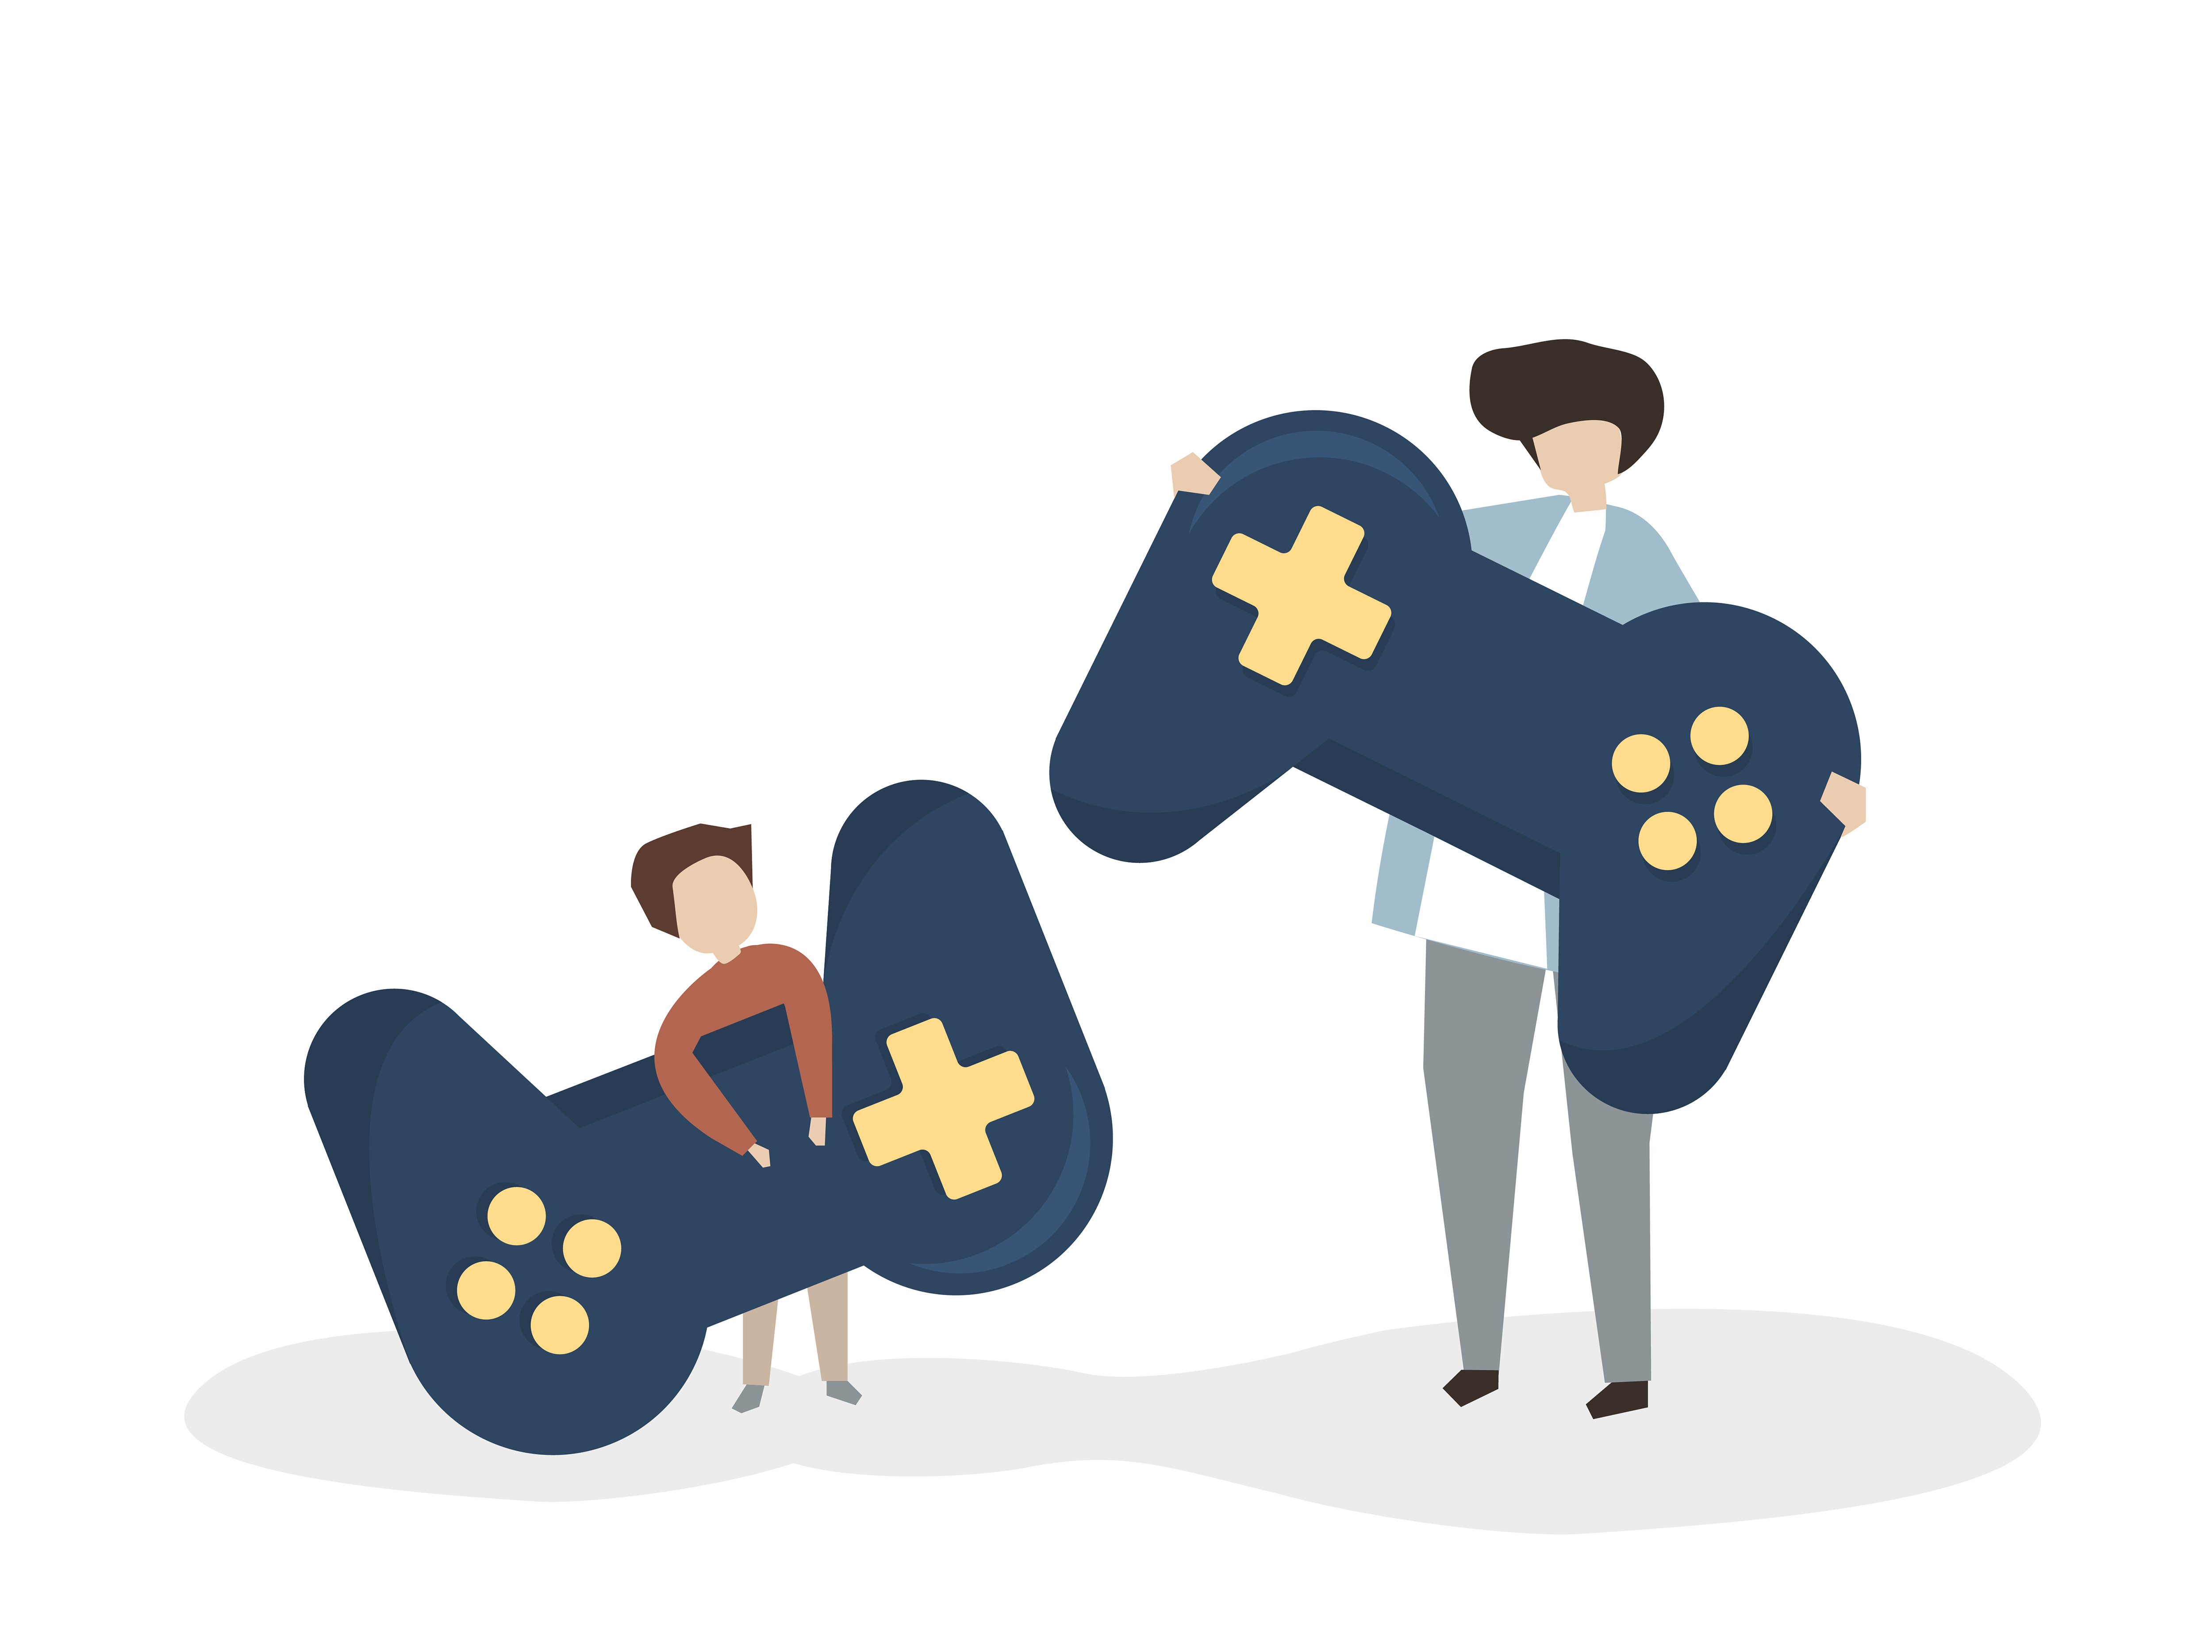

In [67]:
from IPython.display import Image
Image(filename = "/kaggle/input/datasets/salmamorsi/myimage/37168.jpg")

# introduction 


The video game industry has become one of the largest and fastest-growing sectors of the global entertainment market. According to a recent study by Research and Markets, the industry is projected to generate **$293.2 billion in revenue by 2027**, representing approximately **245% growth over the past decade**. The COVID-19 pandemic further accelerated this growth, with the industry expanding at an annual rate of around **14.5%** as gaming became one of the most popular forms of entertainment worldwide.

Contrary to the common perception that video games are primarily for children, modern gaming attracts players of all ages and demographics. The industry has also reached a point where the development of many major titles requires production budgets that rival or even exceed those of Hollywood movies.

Despite its enormous economic and cultural impact, the video game industry has received relatively limited attention in academic research. This project aims to explore video game data through data analysis techniques, identifying trends in sales, genres, critical reception, and other key factors that contribute to the success of video games.


## importing the libraries

In [2]:

import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
from viz_utils import *
import plotly.express as px

#from custom_transformers import *
#from ml_utils import *
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings
from sklearn.experimental import enable_iterative_imputer  # Explicitly enable it
from sklearn.impute import IterativeImputer

from sklearn.ensemble import IsolationForest

/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/publisher_summary.csv
/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/yearly_trends.csv
/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/games.csv
/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/genre_summary.csv
/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/platform_summary.csv
/kaggle/input/datasets/salmamorsi/myimage/37168.jpg


#  Data Ingestion and Inspection 

In [7]:
df = pd.read_csv("/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/games.csv")
pd.set_option('display.max_columns', None)

df.head()

,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,publisher_region,publisher_tier,esrb_rating,metacritic_score,user_score,critic_review_count,user_review_count,na_sales_million,eu_sales_million,jp_sales_million,other_sales_million,global_sales_million,estimated_revenue_million_usd,launch_price_usd,is_sequel,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs
0,G000001,eFootball 2023,Game Boy,Handheld,Nintendo,4,Sports,1990,CD Projekt,Deep Silver,Poland,AAA,M,69,6.7,34,1172,10.01,8.35,2.58,3.46,24.40,575.88,49.99,1,1,1,0,0,0,0,0,0,31.8,86.1
1,G000002,Doom 3,Xbox,Console,Microsoft,6,Rhythm,2004,Ubisoft,Ubisoft,France,AAA,M,78,9.4,5,186,52.28,33.72,5.32,12.30,103.62,5056.51,59.99,1,0,1,1,0,0,0,0,0,13.1,55.4
2,G000003,God of Fire,PC,PC,Various,0,Misc,1988,Microsoft Studios,Microsoft Studios,USA,AAA,T,76,6.6,33,363,2.90,1.48,0.75,0.91,6.04,138.60,59.99,0,0,0,0,0,0,0,0,0,9.8,20.9
3,G000004,Call of Duty: Rising Sun,Mobile (Android),Mobile,Google,0,Shooter,2017,InXile Entertainment,InXile Entertainment,USA,AA,M,62,7.0,28,532,6.76,3.27,0.73,2.34,13.10,36.98,0.00,0,1,1,1,0,0,0,0,0,9.1,44.8
4,G000005,Fortnite 3,Nintendo 64,Console,Nintendo,5,Battle Royale,1999,Naughty Dog,id Software,USA,AAA,AO,62,5.6,58,1280,25.12,15.94,7.02,7.71,55.79,2148.24,69.99,1,1,0,1,0,0,0,0,0,150.8,322.3


In [4]:
df.dtypes

game_id                                object
title                                  object
platform                               object
platform_type                          object
platform_maker                         object
platform_generation                     int64
genre                                  object
year                                    int64
publisher                              object
developer                              object
publisher_region                       object
publisher_tier                         object
esrb_rating                            object
metacritic_score                        int64
user_score                            float64
critic_review_count                     int64
user_review_count                       int64
na_sales_million                      float64
eu_sales_million                      float64
jp_sales_million                      float64
other_sales_million                   float64
global_sales_million              

In [8]:
df.shape

(50000, 35)

In [10]:
df.isnull().sum()

game_id                               0
title                                 0
platform                              0
platform_type                         0
platform_maker                        0
platform_generation                   0
genre                                 0
year                                  0
publisher                             0
developer                             0
publisher_region                      0
publisher_tier                        0
esrb_rating                           0
metacritic_score                      0
user_score                            0
critic_review_count                   0
user_review_count                     0
na_sales_million                      0
eu_sales_million                      0
jp_sales_million                      0
other_sales_million                   0
global_sales_million                  0
estimated_revenue_million_usd         0
launch_price_usd                      0
is_sequel                             0


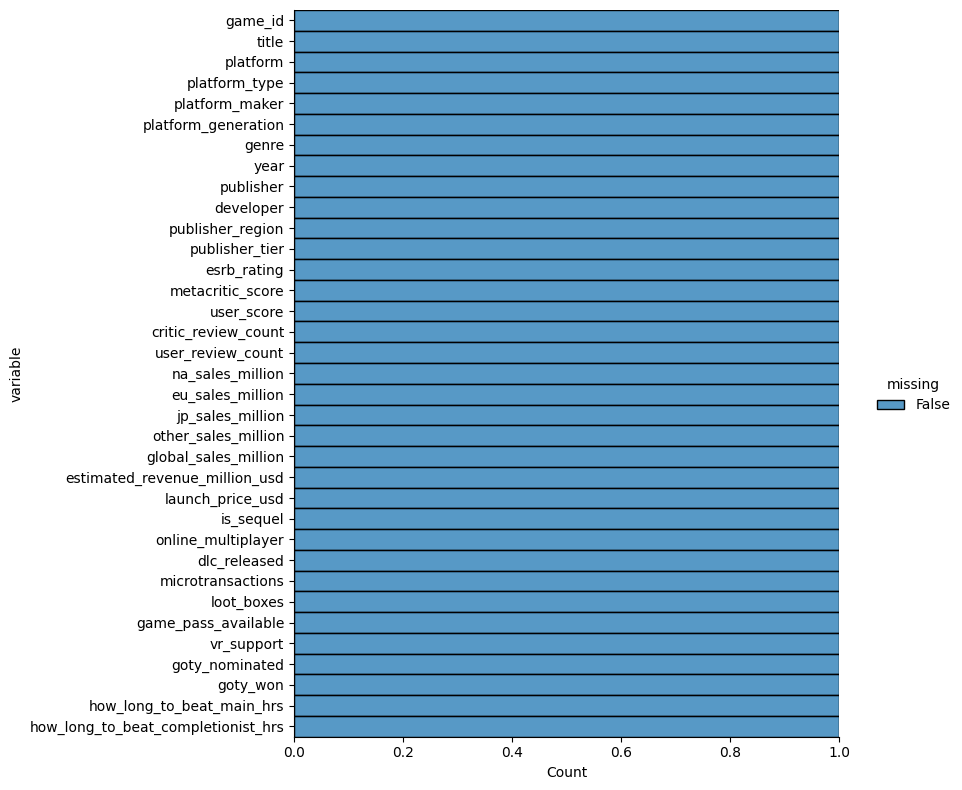

In [12]:
sns.displot(
    data=df.isnull().melt(value_name='missing'),
    y='variable',
    hue='missing',
    multiple='fill',
    height=8,
    aspect=1.1
)



we have no missing values in our data

# 3. Exploratory Data Analysis



## Filtering High-Rated Next-Generation Games

To focus the analysis on modern, critically acclaimed games, the dataset was filtered using three conditions:

> **Release Year ≥ 2020:** Includes only games released during the current console generation.
>
> 
> **Platform:** Selects gamesavailable on either the PlayStation 5 or Xbox Series X.
>
> 
> **Metacritic Score ≥ 85:** Keeps only titles that received strong critical reviews.

In [14]:
df2 = df[(df["year"] >= 2020) & (df["platform"].isin(["PlayStation 5", "Xbox Series X"])) 
& (df["metacritic_score"] >= 85)]

In [15]:
df2.shape

(137, 35)

### Which genres dominate among highly rated games?

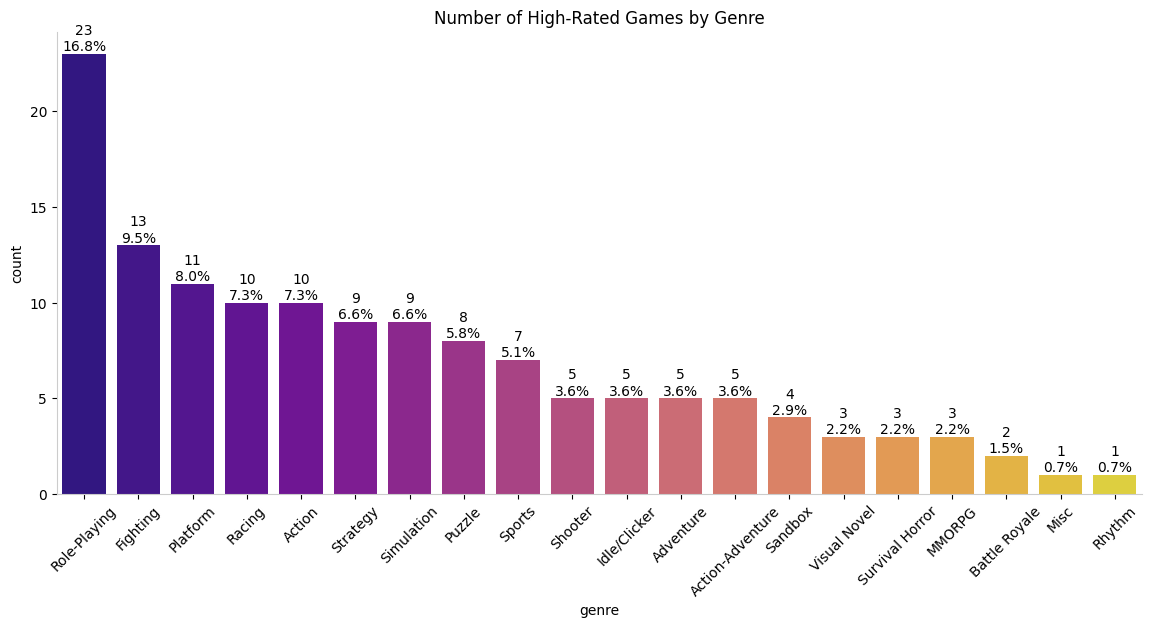

In [28]:
fig, ax = plt.subplots(figsize=(14, 6))

single_countplot(df2, x='genre', ax=ax)
plt.title("Number of High-Rated Games by Genre")

plt.xticks(rotation=45)

plt.show()

In [18]:
df2["platform"].value_counts()

platform
PlayStation 5    137
Name: count, dtype: int64

*we have no xbox highly rated games to compare*

### Do games that critics love also receive high user ratings? 

In [20]:
df2[["metacritic_score","user_score"]].corr().style.background_gradient()

,metacritic_score,user_score
metacritic_score,1.000000,0.395730
user_score,0.395730,1.000000


In [23]:
top_sales = df2.sort_values(
    "global_sales_million",
    ascending=False
).head(10)
top_sales

,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,publisher_region,publisher_tier,esrb_rating,metacritic_score,user_score,critic_review_count,user_review_count,na_sales_million,eu_sales_million,jp_sales_million,other_sales_million,global_sales_million,estimated_revenue_million_usd,launch_price_usd,is_sequel,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs
11446,G011447,The Witcher 4: Eternal,PlayStation 5,Console,Sony,9,Role-Playing,2025,2K Games,2K Games,USA,AAA,M,91,10.0,35,95,120.12,101.38,21.35,43.94,286.79,13456.53,79.99,0,0,1,0,0,0,0,1,0,80.8,286.1
18072,G018073,Warzone 2,PlayStation 5,Console,Sony,9,Battle Royale,2023,FromSoftware,FromSoftware,Japan,AAA,T,93,9.7,16,13,108.99,96.85,35.10,11.95,252.89,9156.79,49.99,1,1,1,1,1,0,0,0,0,120.1,342.3
3574,G003575,Elder Scrolls Online: Reckoning,PlayStation 5,Console,Sony,9,MMORPG,2020,Bandai Namco,InXile Entertainment,Japan,AAA,Not Rated,91,7.9,35,454,109.82,63.26,24.19,37.96,235.23,9845.68,59.99,0,1,0,1,1,0,0,1,0,193.2,694.5
41588,G041589,Halo : Redux,PlayStation 5,Console,Sony,9,Action,2026,Electronic Arts,Electronic Arts,USA,AAA,M,90,7.7,15,144,92.40,54.19,6.36,33.25,186.20,9135.22,49.99,0,1,1,0,0,1,0,0,0,7.6,15.7
42483,G042484,Forza Motorsport 6,PlayStation 5,Console,Sony,9,Racing,2020,Sony Interactive,Rockstar Games,Japan,AAA,T,85,8.2,24,576,89.46,46.44,13.51,19.90,169.31,7262.81,49.99,1,0,1,0,0,0,0,1,1,14.6,39.6
1839,G001840,Age of Empires VIII,PlayStation 5,Console,Sony,9,Strategy,2020,Nintendo,Nintendo,Japan,AAA,Not Rated,94,9.0,28,45,58.81,47.45,37.83,23.13,167.22,7327.72,39.99,1,0,1,1,0,0,0,0,0,48.7,239.1
44101,G044102,Forza Motorsport 3,PlayStation 5,Console,Sony,9,Racing,2025,Bandai Namco,Bandai Namco,Japan,AAA,E10+,86,9.0,26,40,61.65,46.35,31.58,23.48,163.06,7509.14,59.99,1,0,0,1,1,1,0,1,0,18.2,56.8
22970,G022971,MLB The Show 2025,PlayStation 5,Console,Sony,9,Sports,2025,Sega,Electronic Arts,Japan,AAA,M,87,9.0,10,359,64.31,40.02,25.45,23.43,153.21,7603.95,69.99,1,1,1,1,0,0,0,0,0,17.9,70.3
24823,G024824,Lost Knight,PlayStation 5,Console,Sony,9,Action,2022,CD Projekt,CD Projekt,Poland,AAA,E10+,91,9.2,22,553,76.53,39.93,7.71,26.96,151.13,5059.32,59.99,0,0,1,0,0,1,0,1,0,15.4,72.4
35504,G035505,Valheim Reborn,PlayStation 5,Console,Sony,9,Sandbox,2021,Rockstar Games,Rockstar Games,USA,AAA,E10+,87,8.9,48,116,58.29,49.11,7.60,21.51,136.51,6263.26,39.99,0,1,1,1,0,1,0,1,0,143.5,432.2


## Summary Statistics 

### What is the distribution of game sales and launch prices?

In [39]:
summary = (
    df[["global_sales_million", "launch_price_usd"]]
    .agg(["min", "max", "mean", "sum"])
)

summary["global_sales_million"] = summary["global_sales_million"].map(lambda x: f"{x:,.2f}")
summary["launch_price_usd"] = summary["launch_price_usd"].map(lambda x: f"${x:,.2f}")
summary

,global_sales_million,launch_price_usd
min,0.05,$0.00
max,"1,494.68",$79.99
mean,26.03,$42.03
sum,"1,301,736.91","$2,101,442.68"


In [53]:

df_2020 = df[df["year"] >= 2020].copy()

genres = sorted(df_2020["genre"].dropna().unique())

colors = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756",
    "#72B7B2", "#EECA3B", "#B279A2", "#FF9DA6",
    "#9D755D", "#BAB0AC"
]

fig = go.Figure()

for i, genre in enumerate(genres):

    genre_data = df_2020[df_2020["genre"] == genre]

    fig.add_trace(
        go.Box(
            y=genre_data["global_sales_million"],
            name=genre,

            # Box settings
            boxpoints="all",
            boxmean=True,
            notched=True,
            jitter=0.45,
            pointpos=-1.6,
            whiskerwidth=0.7,

            # Marker styling
            marker=dict(
                size=5,
                color=colors[i % len(colors)],
                opacity=0.6
            ),

            fillcolor=colors[i % len(colors)],
            line=dict(color="black", width=1),

            # Hover information
            text=genre_data["title"],
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Genre: %{x}<br>"
                "Global Sales: %{y:.2f} Million"
                "<extra></extra>"
            )
        )
    )

fig.update_layout(
    title="Global Sales Distribution by Genre (Games Released Since 2020)",
    xaxis_title="Genre",
    yaxis_title="Global Sales (Millions)",
    template="plotly_white",
    height=650,
    showlegend=False,
    hovermode="closest"
)

fig.show()

### Which genres are the most commercially successful?

In [51]:
result = df.groupby("genre").agg(
    average_metacritic=("metacritic_score", "mean"),
    total_global_sales=("global_sales_million", "sum")
).sort_values(by="total_global_sales", ascending=False)
result.style.background_gradient()

,average_metacritic,total_global_sales
genre,,
Sports,71.239275,263838.830000
Action,73.497599,208197.930000
Shooter,74.042607,169891.120000
Role-Playing,77.459808,108963.880000
Platform,74.005024,85004.800000
Racing,74.399585,82745.330000
Fighting,74.942050,62525.890000
Simulation,74.436442,53977.480000
Adventure,76.588652,39900.590000


###  How many games have microtransactions  ???

In [55]:
# Shortcut to get percentages directly
df['microtransactions'].value_counts(normalize=True) * 100

microtransactions
0    68.902
1    31.098
Name: proportion, dtype: float64

In [59]:
features = [
    "dlc_released",
    "microtransactions",
    "loot_boxes",
    "game_pass_available"
]



In [60]:
percentage_table = (
    (df[features].mean() * 100)
    .round(2)
    .rename("Percentage")
    .to_frame()
)

percentage_table["Percentage"] = (
    percentage_table["Percentage"].astype(str) + "%"
)

percentage_table

,Percentage
dlc_released,62.31%
microtransactions,31.1%
loot_boxes,6.5%
game_pass_available,3.65%


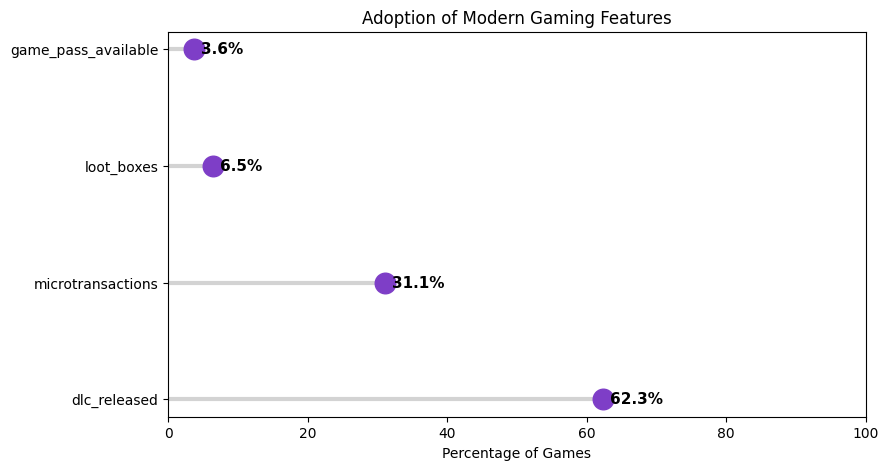

In [63]:


fig, ax = plt.subplots(figsize=(9,5))

ax.hlines(
    y=percentages.index,
    xmin=0,
    xmax=percentages.values,
    color="lightgray",
    linewidth=3
)

ax.scatter(
    percentages.values,
    percentages.index,
    s=220,
    color="#7E3EC7",
    zorder=3
)

for i, value in enumerate(percentages.values):
    ax.text(value + 1,
            i,
            f"{value:.1f}%",
            va="center",
            fontsize=11,
            fontweight="bold")

ax.set_xlim(0,100)
ax.set_xlabel("Percentage of Games")
ax.set_title("Adoption of Modern Gaming Features")

plt.show()

# Feature Engineering

### Which game relied most heavily on North American sales?

In [65]:
# 1. Group by game title and sum up the raw sales figures first
grouped_games = df.groupby('title')[['na_sales_million', 'global_sales_million']].sum()

# 2. Calculate the true share on the total combined sales
grouped_games['Total_NA_Share'] = grouped_games['na_sales_million'] / grouped_games['global_sales_million']

# 3. Sort by the true share and grab the top game
top_game_NA = grouped_games.sort_values(
    by="Total_NA_Share",
    ascending=False
)
# Get the name of the #1 game
print(top_game_NA.index[0])

The Elder Scrolls IX: The Fallen


In [68]:
Image(url="https://tse2.mm.bing.net/th/id/OIP.cWSewXRyTKEzis9AVo-sfAHaEK?rs=1&pid=ImgDetMain&o=7&rm=3")

### top $10$ publishers based on total Global sales and number of games

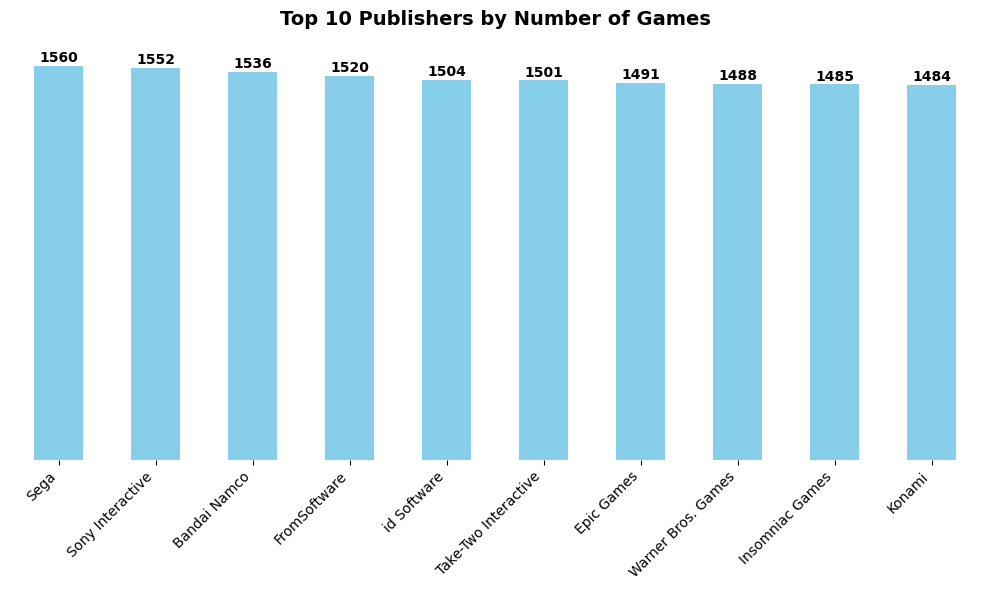

In [69]:
plt.figure(figsize=(10, 6))

top_10_publishers = df['publisher'].value_counts().head(10)
top_10_publishers.plot(kind='bar', color='skyblue')


for spine in ['top', 'right', 'left', 'bottom']:
    plt.gca().spines[spine].set_visible(False)

plt.gca().get_yaxis().set_visible(False)



for i, v in enumerate(top_10_publishers):
    plt.text(
        x=i,           # The horizontal position on the chart
        y=v + 2,       # The vertical position (slightly above the top of the bar)
        s=str(int(v)), # The text label to display (converted to integer)
        ha='center',   # Center the text horizontally over the bar
        va='bottom',   # Align the bottom of the text string to the coordinate
        fontsize=10,
        fontweight='bold',
        color='black'
    )
plt.title('Top 10 Publishers by Number of Games', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Number of Games', fontsize=12, labelpad=10)
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

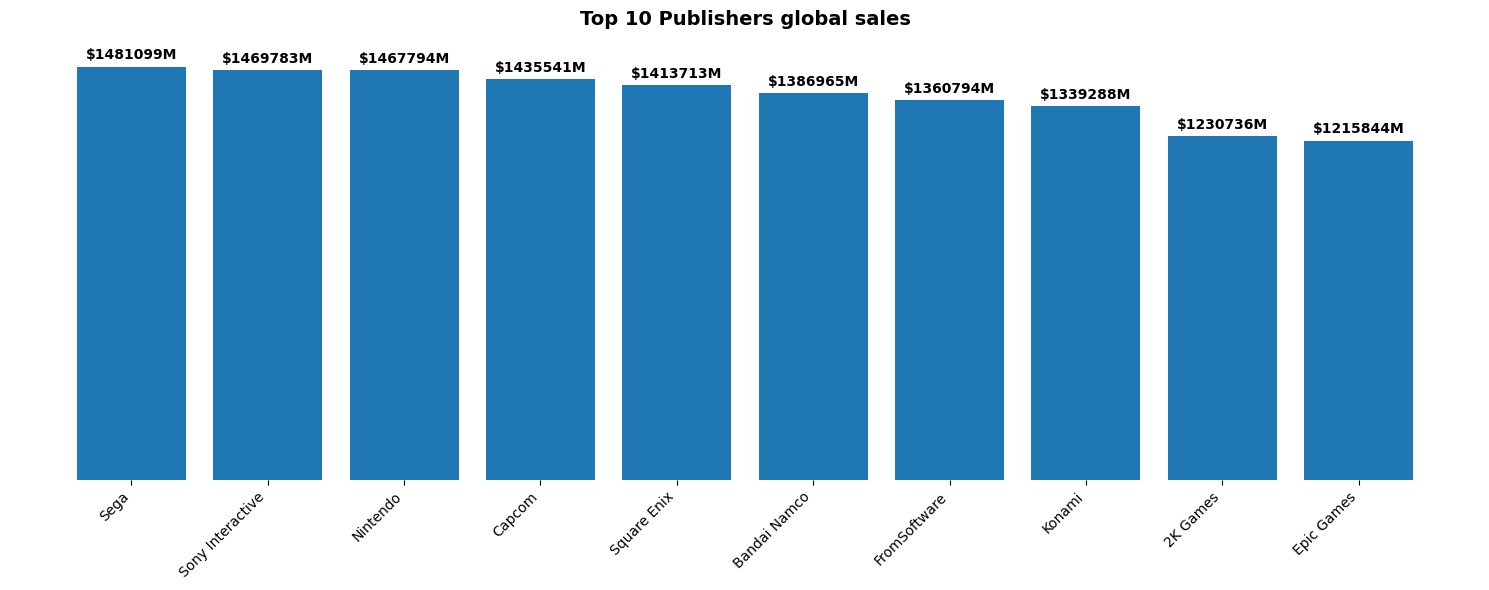

In [70]:
plt.figure(figsize=(15, 6))

top_10_sales = df.groupby('publisher')['estimated_revenue_million_usd'].sum().sort_values(ascending=False).head(10)

plt.bar(x =top_10_sales.index , height = top_10_sales.values)


for spine in ['top', 'right', 'left', 'bottom']:
    plt.gca().spines[spine].set_visible(False)


plt.gca().get_yaxis().set_visible(False)


for i, v in enumerate(top_10_sales):
    plt.text(
        x=i,           
        y=v + (top_10_sales.max() * 0.01), # Dynamic padding: adds 1% of max value above the bar
        s=f"${int(v)}M",                   # Formats it nicely as currency (e.g., $150M)
        ha='center',   
        va='bottom',   
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.title('Top 10 Publishers global sales', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



### Kernel Density Estimate (KDE) 

**The KDE plot illustrates the distribution of Metacritic scores across all games in the dataset. The dashed red line represents the mean Metacritic score, providing a reference for the overall level of critical reception. The shape of the density curve indicates where review scores are most concentrated and whether the distribution is skewed toward higher or lower ratings. This visualization helps determine whether most games receive average reviews or whether critically acclaimed and poorly reviewed titles are more common.**

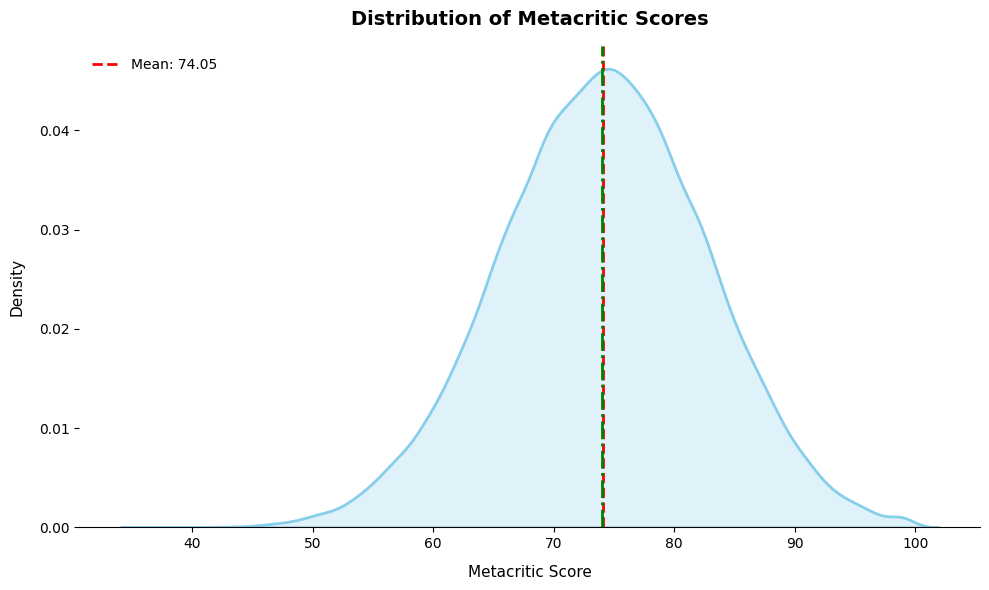

In [76]:
plt.figure(figsize=(10, 6))

# 1. Plot the distribution curve
sns.kdeplot(data=df, x="metacritic_score", fill=True, color="skyblue", linewidth=2)

# 2. Calculate the mean safely using pandas (ignores missing values)
mean_val = df["metacritic_score"].mean()

# 3. Add the vertical mean line
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')

# 4. Clean up the borders to match your design style
for spine in ['top', 'right', 'left']:
    plt.gca().spines[spine].set_visible(False)

# Clean up typography and spacing
plt.title('Distribution of Metacritic Scores', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Metacritic Score', fontsize=11, labelpad=10)
plt.ylabel('Density', fontsize=11, labelpad=10)
plt.legend(frameon=False, loc='upper left') # Removes the box outline around the legend
median_val = df["metacritic_score"].median()

plt.axvline(
    median_val,
    color="green",
    linestyle="-.",
    linewidth=2,
    label=f"Median = {median_val:.2f}"
)

plt.tight_layout()
plt.show()

###  Relationship and Correlation Analysis (pandas + seaborn)


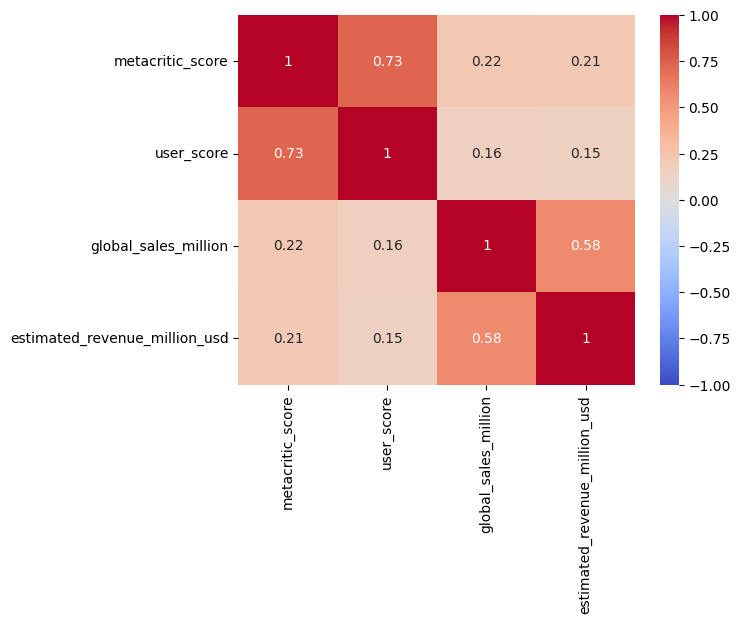

In [77]:
selected_columns = df[["metacritic_score","user_score","global_sales_million","estimated_revenue_million_usd"]]

matrix = selected_columns.corr()

sns.heatmap(matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

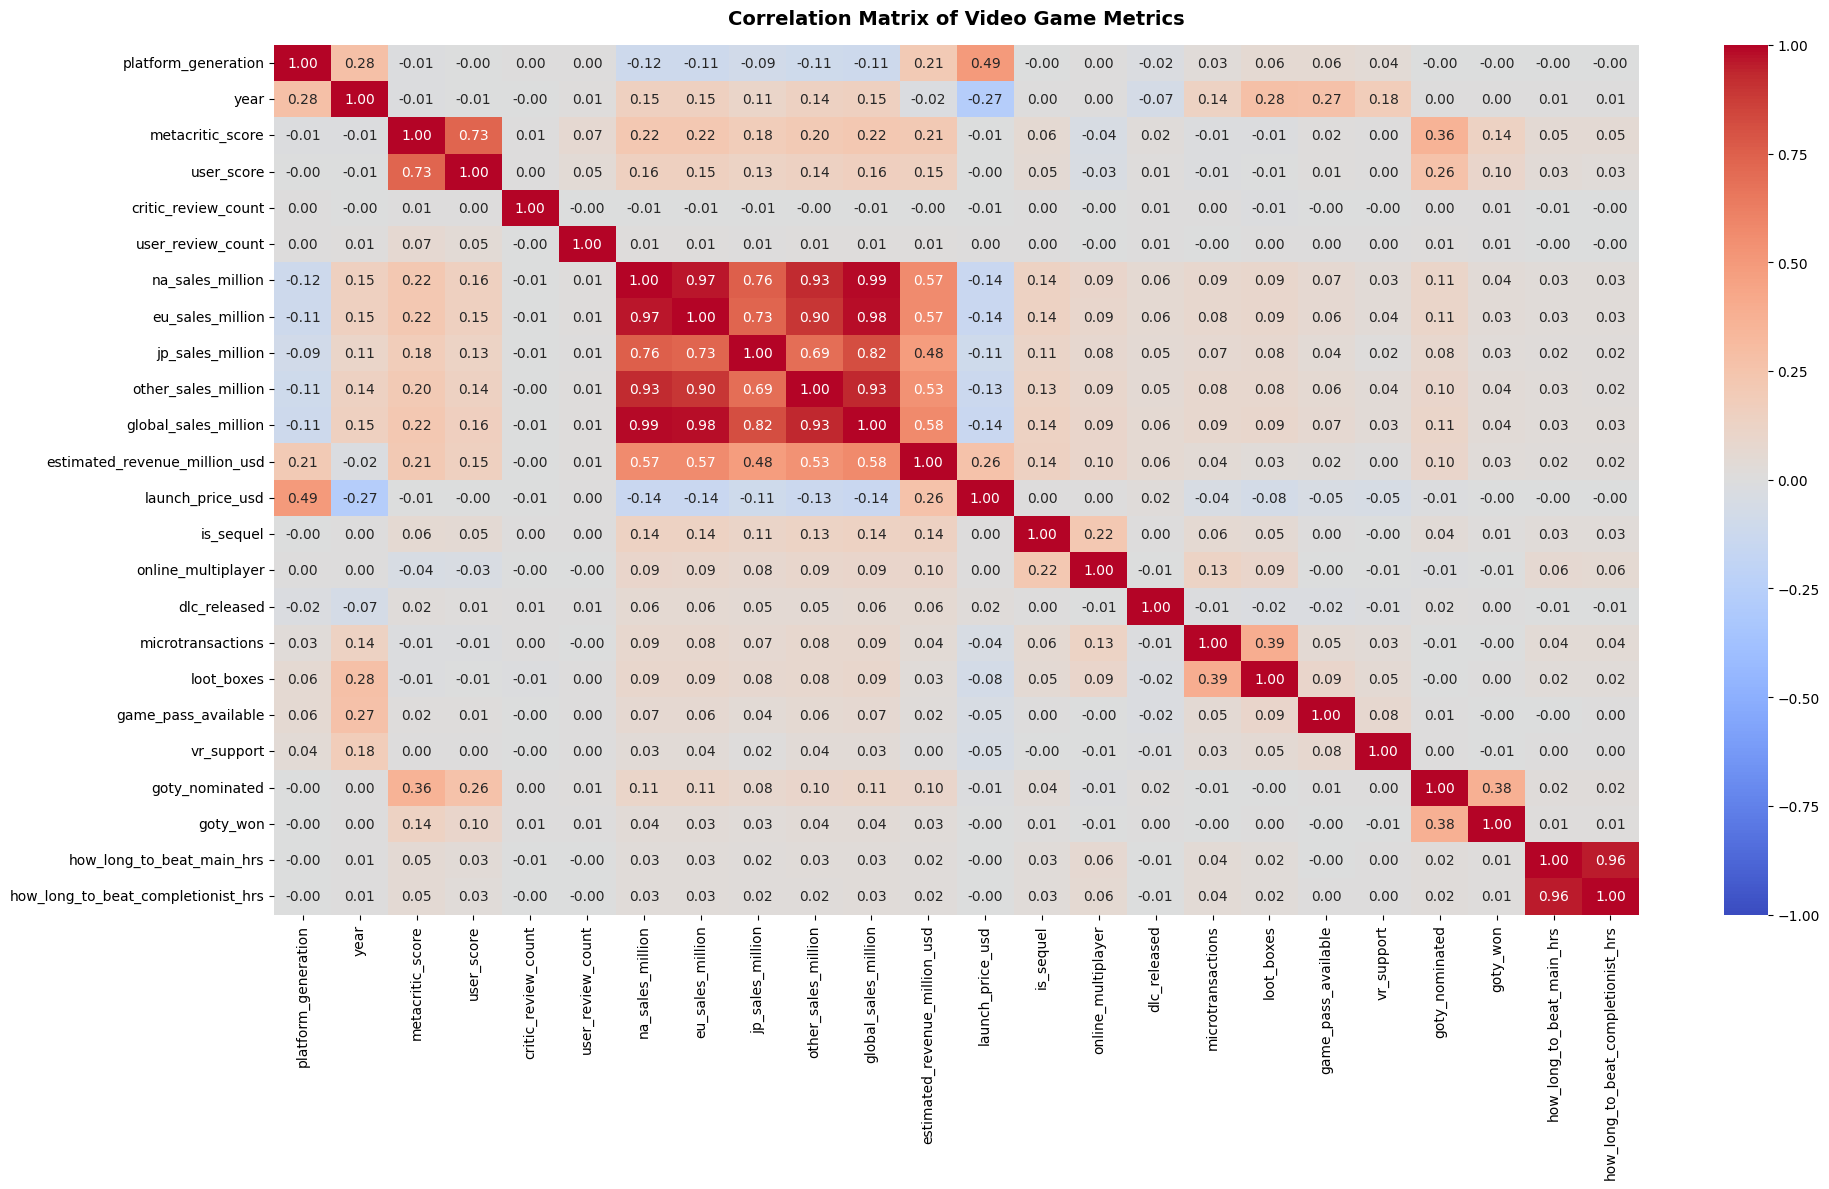

In [78]:
# Create the correlation matrix safely by filtering for numbers only
corr_matrix = df.select_dtypes(include=['number']).corr()

# Plot your exact heatmap code
plt.figure(figsize=(20, 12)) # Added a bit of extra space for readability
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix of Video Game Metrics', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


## Some games are massive hits across multiple consoles, while others are platform exclusives.

### Which games were released on the largest number of platforms?



In [79]:
top_5games =df.groupby('title')['platform'].nunique().sort_values(ascending=False).head(5)
top_5games

title
MLB The Show 2026    33
Madden NFL 2024      33
UFC 3                33
Overwatch 5          33
UFC 4                33
Name: platform, dtype: int64

## the disagreement between critics and players

In [87]:
df["score_diff"]= abs(df["metacritic_score"] -df["user_score"]*10)

In [88]:
biggest3differences = df.sort_values(by="score_diff", ascending=False).head(3)

In [89]:
print(biggest3differences[["title", "metacritic_score", "user_score", "score_diff"]])

                    title  metacritic_score  user_score  score_diff
26405     Valorant Legacy                87         5.7        30.0
32292         Titanfall 6                83         5.3        30.0
13903  Super Mario Legend                71         4.2        29.0


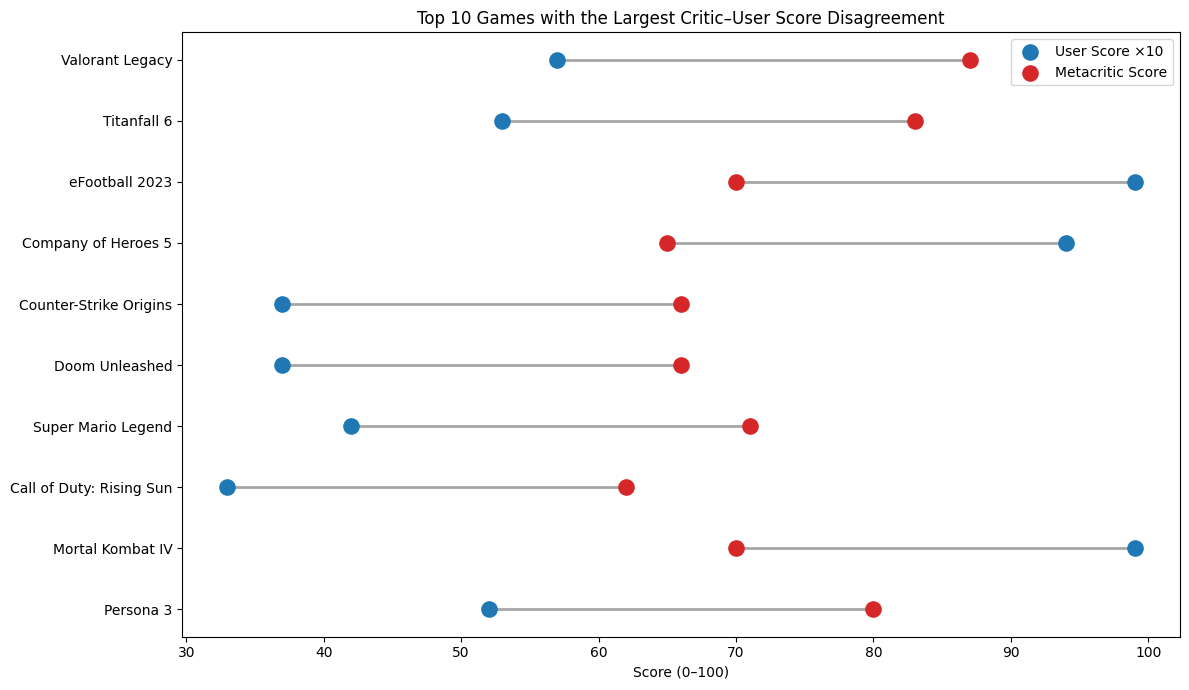

In [91]:

top10 = (
    df.sort_values("score_diff", ascending=False)
      .head(10)
      .sort_values("score_diff")
)

fig, ax = plt.subplots(figsize=(12, 7))

# Connecting lines
for i in range(len(top10)):
    ax.plot(
        [top10["user_score"].iloc[i] * 10,
         top10["metacritic_score"].iloc[i]],
        [i, i],
        color="gray",
        linewidth=2,
        alpha=0.7
    )

# User scores
ax.scatter(
    top10["user_score"] * 10,
    range(len(top10)),
    s=120,
    color="#1f77b4",
    label="User Score ×10",
    zorder=3
)

# Critic scores
ax.scatter(
    top10["metacritic_score"],
    range(len(top10)),
    s=120,
    color="#d62728",
    label="Metacritic Score",
    zorder=3
)

ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10["title"])

ax.set_xlabel("Score (0–100)")
ax.set_title("Top 10 Games with the Largest Critic–User Score Disagreement")

ax.legend()

plt.tight_layout()
plt.show()

###  Segmenting by Release Era
* Let's see how game characteristics changed over time.



In [92]:
gaming_eras = {
    "The 8-Bit & 16-Bit Era " :1995,     #1985-1995
    "The 3D Era" :2005,             #1996-2005
    "The Online & HD Era ":2014,   #2006-2014
    "The Modern & UH3D Era":2026   #2015- present
}

In [93]:
df["era"] = pd.cut(df["year"], bins =[1985] +list(gaming_eras.values()) , labels = list(gaming_eras.keys()))

###  Which genres dominated each era?

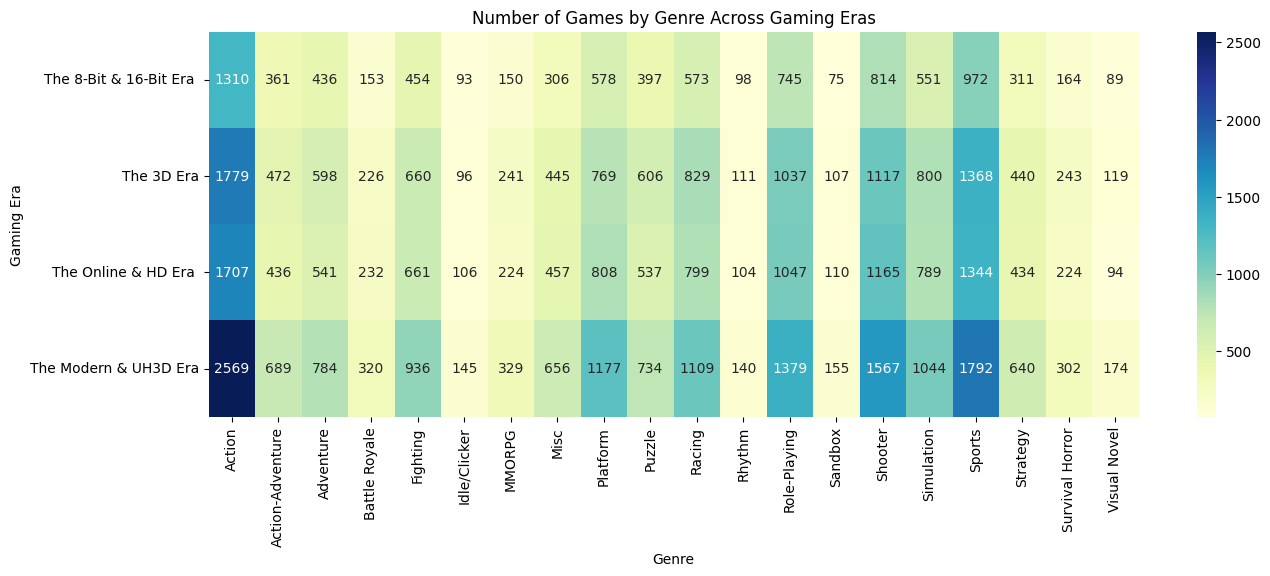

In [96]:
genre_era = pd.crosstab(df["era"], df["genre"])

plt.figure(figsize=(15,5))

sns.heatmap(
    genre_era,
    annot=True,
    cmap="YlGnBu",
    fmt="d"
)

plt.title("Number of Games by Genre Across Gaming Eras")
plt.xlabel("Genre")
plt.ylabel("Gaming Era")

plt.show()

In [99]:
flow = (
    df.groupby(["era", "genre"])
      .size()
      .reset_index(name="count")
)


eras = flow["era"].unique().tolist()
genres = flow["genre"].unique().tolist()

nodes = eras + genres

node_indices = {node: i for i, node in enumerate(nodes)}


source = flow["era"].map(node_indices)
target = flow["genre"].map(node_indices)
value = flow["count"]


fig = go.Figure(go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
))

fig.update_layout(
    title="Flow of Game Genres Across Gaming Eras",
    font_size=12,
    height=650
)

fig.show()

> Challenge 14: Filtering the Heavy Hitters
We want to look at niche publishers vs. industry titans.

> Task: Filter your DataFrame to keep only publishers who have released more than 50 games in total. Save this as a new DataFrame called df_major_publishers.

> Hint: Look into using .groupby().filter().

In [ ]:
result = df.groupby('publisher').filter(lambda x: len(x) > 50)
print(result['publisher'].unique())

> Challenge 15: The "All-Star" Publishers
Let's find publishers who consistently pump out high-quality games, rather than just getting lucky once.

> Task: Group the data by publisher and calculate two things at once: the count of games they made and the median Metacritic score. Filter for publishers with at least 10 games, and sort them by the highest median score.

> Hint: Use .agg(['count', 'median']).

In [ ]:
publishers_info = df.groupby("publisher").agg(
    game_count=("title", "count"),
    median_score=("metacritic_score", "median")
)
filtered_publishers = publishers_info[publishers_info["game_count"] >= 10]

filtered_publishers.sort_values(by="median_score", ascending=False).head(10)

> Challenge 16: The Sales Outlier 

> Are global sales driven by a few massive hits, or do most games perform similarly?

> Task: Create a Box Plot of global_sales_million split across different game genres.

> Visualization Goal: Clean up the chart by removing the top/right spines, turning off the y-axis grid lines, and giving each genre a unique color palette.

In [ ]:
plt.figure(figsize=(20, 12))

# Use seaborn to split global sales by genre effortlessly
ax = sns.boxplot(
    data=df, 
    x="genre", 
    y="global_sales_million", 
    palette="Set2"  # Gives each genre a unique color palette
)

# Clean up the chart borders
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# Keep the bottom spine but make it a subtle color
ax.spines['bottom'].set_color('#cccccc')

# Turn off the y-axis grid lines (Challenge Goal)
ax.yaxis.grid(False) 
ax.xaxis.grid(False)

# Styling typography
plt.title('Global Sales Distribution across Video Game Genres', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('') # Drop the redundant 'genre' label
plt.ylabel('Global Sales (Millions USD)', fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

> Challenge 17: Completionist Efficiency (Value for Money)
Let's find out which genres offer the most gameplay hours per dollar spent.

> Task: Calculate a new feature called hours_per_dollar using hours to beat (completionist) and price (or estimated revenue/cost metrics if price isn't directly available). Group by genre and create a Horizontal Bar Chart showing the average value for money per genre, sorted from highest to lowest. Annotate the bars with the values!

how_long_to_beat_completionist_hrs


estimated_revenue_million_usd


In [ ]:
hours_per_value = df.groupby("genre").agg(
    AVGmoney = ("estimated_revenue_million_usd" , "mean"),
    AVGhours = ("how_long_to_beat_completionist_hrs" , "mean")
).sort_values(by = "AVGmoney" ,ascending = True)

In [ ]:
hours_per_value

In [ ]:
plt.figure(figsize=(20, 12))
plt.barh(hours_per_value.index,hours_per_value["AVGmoney"])

In [ ]:


# 1. Calculate row-level efficiency
df["hours_per_revenue"] = df["how_long_to_beat_completionist_hrs"] / df["estimated_revenue_million_usd"]

# 2. CRITICAL FIX: Keep only rows with valid, finite numbers (removes NaN and Inf)
df_clean = df[np.isfinite(df["hours_per_revenue"])]

# 3. Group by genre using the cleaned data
genre_efficiency = df_clean.groupby("genre")["hours_per_revenue"].mean().sort_values(ascending=True)

# 4. Setup the horizontal chart
plt.figure(figsize=(12, 8))
ax = plt.gca()
bars = ax.barh(genre_efficiency.index, genre_efficiency.values, color='teal')

# 5. Clean styling
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)
ax.get_xaxis().set_visible(False) 

# 6. Add Annotations
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        text=f"{width:.1f} hrs/$M",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(8, 0),                  
        textcoords="offset points",
        va='center',                    
        ha='left',                      
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.title('Video Game Value by Genre (Hours of Gameplay per Million USD Revenue)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

> Challenge 18: Title Length vs. Popularity
Does a short, snappy game title sell better than a super long one?

> Task: Create a new column called title_length that counts the number of characters in the game's title. Then, calculate the correlation coefficient between title_length and global_sales_million. Is there any meaningful relationship?

In [ ]:
df["title_length"] = df["title"].str.len()

df["title_length"].corr(df["global_sales_million"])

*as we can see here there is no correlation at all*

> Challenge 19: Finding Specific Keywords
Let's see how many games in your dataset belong to major recurring trends or spin-offs.

> Task: Filter the dataset to find all games that contain the word "Edition", "Remaster", or "Remake" in their title (case-insensitive). What percentage of the total dataset do these updated releases represent?

> Hint: Check out the .str.contains() method with the case=False argument.

In [ ]:
words = ['edition', 'remaster', 'remake']

regex_pattern = '|'.join(words)

filtered_df = df[df['title'].str.contains(regex_pattern, case=False, na=False)]

In [ ]:
filtered_df

In [ ]:
percentage = (len(filtered_df) / len(df)) * 100

print(f"Percentage of updated releases: {percentage:.2f}%")

> Challenge 20: The Ultimate Pivot Table
Let's create a comprehensive summary grid that crosses two categorical variables.

> Task: Build a pivot table where the rows are the game genres, the columns are the publisher regions (e.g., USA, Japan, Europe), and the values inside the grid show the average global sales.

> Hint: Use pd.pivot_table(). Fill any missing NaN values in the resulting grid with 0

In [ ]:
df.columns

In [ ]:
pivot = df.pivot_table(index="genre", columns="publisher_region", values="global_sales_million", aggfunc="mean" , fill_value =0)
pivot.style.background_gradient(cmap='YlGnBu', axis=None).format("{:.2f}")

# LEVEL : Advanced 

In [ ]:
df.columns

In [ ]:
df["platform"]

> Challenge 21: The Platform One-Hot Encoding & Sparsity Check
Before feeding categorical data into a Machine Learning model (like a linear regression or neural network), we must convert it to numbers.

> Task: Convert the platform column into dummy/one-hot encoded variables. Append these new columns to your original DataFrame. Finally, calculate the sparsity of the resulting platform columns (the percentage of zeros vs. total elements in those columns).

> Hint: Explore pd.get_dummies().

In [ ]:
df_encoded = pd.get_dummies(df, columns=['platform'], dtype=int)
print(df_encoded)

In [ ]:
df_encoded.columns

In [ ]:

# 1. Isolate the platform columns AND force them to be strictly numeric
platform_cols = df_encoded.filter(like='platform_').select_dtypes(include=[np.number])

# 2. Count the total number of cells in these columns (rows × columns)
total_elements = platform_cols.size

# 3. Now summing will work flawlessly because it's purely numbers!
total_ones = platform_cols.sum().sum()

# 4. Calculate the zeros and the final sparsity percentage
total_zeros = total_elements - total_ones
sparsity_percentage = (total_zeros / total_elements) * 100

print(f"Total elements in platform matrix: {total_elements:,}")
print(f"Sparsity Percentage: {sparsity_percentage:.2f}%")

>  Challenge 22: Target Encoding for High-Cardinality Categorical FeaturesOne-hot encoding a column with hundreds of unique values (like publisher) creates too many columns. Instead, we can use Target Encoding.
>
>
> Task: Create a new column called publisher_encoded. For every row, this column should contain the average global sales of that specific publisher—but to prevent data leakage, exclude the current row's sales from that average calculation.
>
>
>
> Hint: This requires calculating the leave-one-out mean: $\frac{(\text{Sum of Group} - \text{Current Value})}{(\text{Count of Group} - 1)}$ 

In [ ]:
# 1. Calculate the total sales sum and total game count per publisher
publisher_sums = df.groupby("publisher")["global_sales_million"].transform("sum")
publisher_counts = df.groupby("publisher")["global_sales_million"].transform("count")

# 2. Apply the Leave-One-Out formula to exclude the current row's sales
# We use np.where to handle new/unique publishers where count - 1 would equal 0
df["publisher_encoded"] = np.where(
    publisher_counts > 1,
    (publisher_sums - df["global_sales_million"]) / (publisher_counts - 1),
    df["global_sales_million"] # Fallback if it's the only game from that publisher
)

> Challenge 23: Logarithmic Transformation for Highly Skewed DistributionsSales numbers are often heavily right-skewed (a few games sell millions, most sell very little), which can break machine learning models that assume normally distributed data.
>
>
> Task: Create a new column global_sales_log using a natural log transformation. Handle cases where sales might be exactly $0$ using $log(x + 1)$. Plot a single figure showing side-by-side distribution plots (Histograms with KDE curves) comparing the raw sales vs. the log-transformed sales to verify the skewness correction.

In [ ]:

df["global_sales_log"] = np.log1p(df["global_sales_million"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df["global_sales_million"], kde=True, ax=axes[0], color="crimson")
axes[0].set_title("Original Global Sales Distribution (Heavy Skew)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Sales (Millions USD)")

sns.histplot(df["global_sales_log"], kde=True, ax=axes[1], color="royalblue")
axes[1].set_title("Log-Transformed Sales Distribution (Normalized)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Log(Sales + 1)")

for ax in axes:
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

> Challenge 24: Year-over-Year (YoY) Growth Metrics
We want to track the financial health of the gaming industry over time.

> Task: Calculate the total global sales for every year in the dataset. Then, create a window function to calculate the Year-over-Year (YoY) growth percentage in sales (e.g., how much did 2011 sales grow or shrink compared to 2010?).

> Hint: Look into .groupby() combined with the .pct_change() window method.

In [ ]:
df.columns

In [ ]:
salesperyear = df.groupby("year")["global_sales_million"].sum()

yoy_growth = salesperyear.pct_change() * 100

yoy_report = pd.DataFrame({
    "Total_Sales_Millions": salesperyear,
    "YoY_Growth_Percent": yoy_growth
})

print(yoy_report)

> Challenge 25: The Running Cumulative Dominance
Let's see how genres built up their market dominance over history.

> Task: Create a new DataFrame that tracks the cumulative running total of global sales over time (ordered chronologically by year), broken down by genre.

> Hint: Look into the .cumsum() window function applied across grouped time elements.

In [ ]:
newdf = df.sort_values('year').groupby('genre')['global_sales_million'].cumsum()


In [ ]:
# 1. Sort the entire dataset chronologically first
df_sorted = df.sort_values(by="year").copy()

# 2. Calculate the cumulative total and assign it to a new column
df_sorted["cumulative_genre_sales"] = df_sorted.groupby("genre")["global_sales_million"].cumsum()

# 3. Keep a clean view of the tracking columns
genre_dominance = df_sorted[["year", "genre", "global_sales_million", "cumulative_genre_sales"]]

print(genre_dominance.tail(15))

In [ ]:
# Create a historical timeline matrix of genre dominance
timeline_matrix = df_sorted.pivot_table(
    index="year", 
    columns="genre", 
    values="cumulative_genre_sales", 
    aggfunc="max" # Takes the highest cumulative total reached in that year
).ffill()         # Forward-fills any years where a genre didn't release a game

print(timeline_matrix.tail())

> Challenge 26: Finding the "Peak Era" via Rolling Windows
An industry trend can last a few years. Let's find the most lucrative 3-year consecutive window in gaming history.

> Task: Aggregate total global sales by year. Then, use a 3-year rolling window to find which consecutive 3-year block generated the highest average global sales.

> Hint: Investigate the .rolling(window=3) method.

In [ ]:
df['3years'] = df.groupby('year')['global_sales_million'].rolling(window=3).sum().reset_index(level=0, drop=True)


In [ ]:
# 1. Aggregate total sales by year to get a clean chronological timeline
yearly_sales = df.groupby("year")["global_sales_million"].sum().sort_index()

# 2. Calculate the 3-year rolling sum across consecutive years
# (e.g., Year 2010 value will be the sum of 2008 + 2009 + 2010)
rolling_3yr = yearly_sales.rolling(window=3).sum()

# 3. Combine them into a clear evaluation DataFrame
peak_era_df = pd.DataFrame({
    "Yearly_Sales": yearly_sales,
    "3_Year_Rolling_Total": rolling_3yr
})

# 4. Find the absolute highest 3-year window in history
peak_era = peak_era_df.sort_values(by="3_Year_Rolling_Total", ascending=False).head(1)
print(peak_era)

> Challenge 27: Massive Memory Optimization Audit
Large datasets can slow down production servers. Let's optimize memory footprint.

> Task: Check the initial memory usage of your DataFrame using .info(). Optimize the dataset by downcasting numeric columns to smaller bit-sizes (e.g., float64 to float32) and converting low-cardinality text columns (like genre or platform) into the category dtype. Print out the exact percentage of memory saved.

In [ ]:
df.info()

In [ ]:
float64_cols = list(df.select_dtypes(include='float64'))
df[float64_cols] = df[float64_cols].astype('float32')
df[["genre" , "platform"]] = df[["genre" , "platform"]].astype("category")

In [ ]:
df.info()

In [ ]:
# 1. Check your new memory footprint
optimized_memory = df.memory_usage(deep=True).sum()

# 2. Print out the results (assuming you ran this check before downcasting too!)
# (If you didn't save the old footprint, you can read a fresh copy of the raw data to check)
raw_df = pd.read_csv("/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/games.csv") # Quick load to compare
original_memory = raw_df.memory_usage(deep=True).sum()

# 3. Calculate the percentage saved
bytes_saved = original_memory - optimized_memory
pct_saved = (bytes_saved / original_memory) * 100

print(f"Original Memory: {original_memory / (1024**2):.2f} MB")
print(f"Optimized Memory: {optimized_memory / (1024**2):.2f} MB")
print(f"Successfully slashed memory usage by {pct_saved:.2f}%!")

> Challenge 28: Custom Cohort Analysis
We want to track how publishers "age" over time based on their debut.

> Task: Define a publisher's "Cohort Year" as the year of their very first game release in the dataset. Create a matrix that tracks the number of active publishers from each cohort year who were still releasing games 5, 10, and 15 years after their debut.

In [ ]:
df["cohort_year"] = df.groupby("publisher")["year"].transform("min")
df["years_since_debut"] = df["year"] - df["cohort_year"]

In [ ]:
publisher_lifespans = df.groupby(["cohort_year", "publisher"])["years_since_debut"].max().reset_index()

publisher_lifespans["active_at_5_yrs"]  = publisher_lifespans["years_since_debut"] >= 5
publisher_lifespans["active_at_10_yrs"] = publisher_lifespans["years_since_debut"] >= 10
publisher_lifespans["active_at_15_yrs"] = publisher_lifespans["years_since_debut"] >= 15

cohort_matrix = publisher_lifespans.groupby("cohort_year").agg(
    total_started=('publisher', 'count'),
    survived_5_yrs=('active_at_5_yrs', 'sum'),
    survived_10_yrs=('active_at_10_yrs', 'sum'),
    survived_15_yrs=('active_at_15_yrs', 'sum')
)

print(cohort_matrix)

> Challenge 29: Matrix Factorization Prep (User-Critic Preference Matrix)
If you wanted to build a recommendation engine, you'd need a clean utility matrix.

> Task: Pivot the dataset so that publisher forms the rows and genre forms the columns. The values inside should be the average Metacritic score. Use Iterative Imputer or a specialized KNN algorithm from sklearn (or custom logic) to mathematically predict and fill the missing cells based on similar rows, rather than just filling with a flat zero.

In [ ]:
preference_matrix = df.pivot_table(
    index="publisher", 
    columns="genre", 
    values="metacritic_score", 
    aggfunc="mean"
)

In [ ]:
print(preference_matrix.head())

*we have no null values so no need for this step*

> Challenge 30: The Ultimate Outlier Isolation Forest
Standard boxplot thresholds can miss multi-dimensional outliers.

> Task: Use an Isolation Forest unsupervised machine learning model (from sklearn.ensemble) using features like global_sales_million, metacritic_score, and title_length to flag the top 1% most anomalous, bizarre game entries in your dataset. Print out their names and why they are statistical anomalies.

In [ ]:
features = ["global_sales_million", "metacritic_score"]
X = df[features].dropna()
iso_forest = IsolationForest(contamination=0.03, random_state=42)

X_predictions = iso_forest.fit_predict(X)

df["is_outlier"] = 1
df.loc[X.index, "is_outlier"] = X_predictions



In [ ]:
outliers = df[df["is_outlier"] == -1]

In [ ]:
print(f"Total Outliers Detected: {len(outliers)}")
print("\n---  TOP OUTLIER GAMES DETECTED  ---")
print(outliers[["title", "genre", "global_sales_million", "metacritic_score"]].head(10))